In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

In [49]:
import sys
import sys
sys.path.append(r"C:\Users\Rakesh\Documents\summer-project\src")

from two_level_mc import * # adjust if your notebook is nested differently
from functions_v2 import *

In [9]:
import shutil, os
pycache = r"C:\Users\Rakesh\Documents\summer-project\__pycache__"
if os.path.exists(pycache):
    shutil.rmtree(pycache)
    print("Deleted __pycache__")

In [19]:
import numpy as np
import networkx as nx

In [21]:
edges, n_vertices, weights = load_graph(r"../../data/raw/road-minnesota.mtx")
print(f"n_vertices={n_vertices}, edges={len(edges)}")

✓ Loaded: ../../data/raw/road-minnesota.mtx
  Vertices : 2642
  Edges    : 3303
  Weighted : no

n_vertices=2642, edges=3303


In [23]:
check_connectivity(edges, n_vertices)

Components: 2
  Component sizes: [2640, 2]
  -> Call filter_to_largest_component() before proceeding to Phase 1



2

In [25]:
# filter out smaller disconnected components
edges, n_vertices = filter_to_largest_component(edges, n_vertices)

Components: 2
  Component sizes: [2640, 2]
✓ Filtered to largest component
  Vertices : 2642 -> 2640 (dropped 2)
  Edges    : 3303 -> 3302



In [27]:
A, D, L = build_graph_matrices(edges, n_vertices)

✓ Phase 1 complete: A, D, L built as sparse matrices
  Matrix size : 2640 x 2640
  Degree range: [1, 5]
  Non-zeros in L: 9244



In [29]:
lambda_min = compute_lambda_min(L, D)
print(lambda_min)

✓ lambda_min = 0.000341
  (eigenvalues found: [0.         0.00034134])
0.0003413419336890162


In [31]:
L_sigma = build_shifted_laplacian(L, D, lambda_min, sigma_squared=0.25)

✓ Phase 2 complete: L_sigma built (sigma^2 = 0.25)
  L_sigma type: sparse



In [33]:
u, f, B, factor = run_phase3(L_sigma, lambda_min, edges, n_vertices)

✓ Phase 3 complete: correlated field u generated
  u range: [-1.6178, 1.5581]



C:\Users\Rakesh\Documents\summer-project\functions_v2.py:440: CholmodTypeConversionWarning: converting matrix of class csr_matrix to CSC format
  factor = sparse_cholesky(L_sigma)


In [35]:
k = compute_permeability(u, edges)

In [37]:
k

array([4.70476641, 4.67838997, 4.5346728 , ..., 0.21865157, 0.28679837,
       2.25865017])

In [41]:
G_nx = nx.Graph()
G_nx.add_edges_from(edges)

In [43]:
gamma_in, gamma_out, diameter = find_diameter_endpoints(G_nx, n_sample=5, k_hop=4)

In [46]:
gamma_in, gamma_out, diameter

([2368, 2403, 2404, 2405, 2410, 2413, 2395, 2621, 2399],
 [0, 34, 6, 7, 13, 14, 15, 16],
 99)

In [52]:
# checking boundary fraction
check_boundary_fraction(gamma_in, gamma_out, n_vertices, verbose=True)

gamma_in: 9, gamma_out: 8, n_vertices: 2640
Boundary fraction: 0.6439%
  -> Likely safe for aggregation (comparable to validated successes).


0.006439393939393939

In [55]:
aggregate_of, n_coarse = build_capped_aggregation(G_nx, gamma_in, gamma_out, max_size=10)

print(f"n_coarse: {n_coarse} (from {n_vertices} fine vertices, "
      f"{n_vertices/n_coarse:.1f}x reduction)")

n_coarse: 1229 (from 2640 fine vertices, 2.1x reduction)


In [58]:
setup = TwoLevelSetup.build(
    edges, n_vertices, L_sigma, lambda_min,
    gamma_in, gamma_out,
    build_incidence_matrix, sparse_cholesky,
    max_size=10,
    verbose=True
)

gamma_in: 9, gamma_out: 8, n_vertices: 2640
Boundary fraction: 0.6439%
  -> Likely safe for aggregation (comparable to validated successes).
n_coarse: 1229 (1229 aggregates)
Size distribution -- min: 2, max: 4, mean: 2.15
Singletons: 0 (0.0%)
gamma_in_coarse: 5, gamma_out_coarse: 4
Overlap (must be empty): set()
Interior coarse vertices: 1220 (99.3%)
coarse edges: 1844 (from 3302 fine edges)


C:\Users\Rakesh\Documents\summer-project\src\two_level_mc.py:408: CholmodTypeConversionWarning: converting matrix of class csr_matrix to CSC format
  factor = sparse_cholesky(L_sigma)


In [60]:
result = run_paired_validation(setup, N=300)
estimate = two_level_estimate(setup, result, N_coarse_only=2000)

N = 300 paired samples
Q_fine   : mean=26.763350  var=55502.300965
Q_coarse : mean=47.233900  var=172005.090064
Q_fine - Q_coarse : mean=-20.470550  var=32096.008629
Correlation(Q_fine, Q_coarse): 1.0000
Variance reduction: 1.73x
Coarse-only base estimate (N=2000): 92.247199
Correction term mean (paired samples): -20.470550
Two-level estimate of E[Q_fine]: 71.776649
Direct fine-only mean (for comparison): 26.763350


In [62]:
import numpy as np
running_mean_coarse = np.cumsum(result['Q_coarse_samples']) / np.arange(1, 301)
print("Q_coarse running mean, every 50 samples:")
print(running_mean_coarse[::50])

Q_coarse running mean, every 50 samples:
[3.78767843e-05 3.45215836e+00 6.78107759e+01 7.24043560e+01
 5.89626831e+01 4.84280415e+01]


In [64]:
result = run_paired_validation(setup, N=1000)
estimate = two_level_estimate(setup, result, N_coarse_only=2000)

N = 1000 paired samples
Q_fine   : mean=51.680631  var=786840.359299
Q_coarse : mean=91.347335  var=2468576.926823
Q_fine - Q_coarse : mean=-39.666704  var=468042.403796
Correlation(Q_fine, Q_coarse): 1.0000
Variance reduction: 1.68x
Coarse-only base estimate (N=2000): 92.247199
Correction term mean (paired samples): -39.666704
Two-level estimate of E[Q_fine]: 52.580495
Direct fine-only mean (for comparison): 51.680631


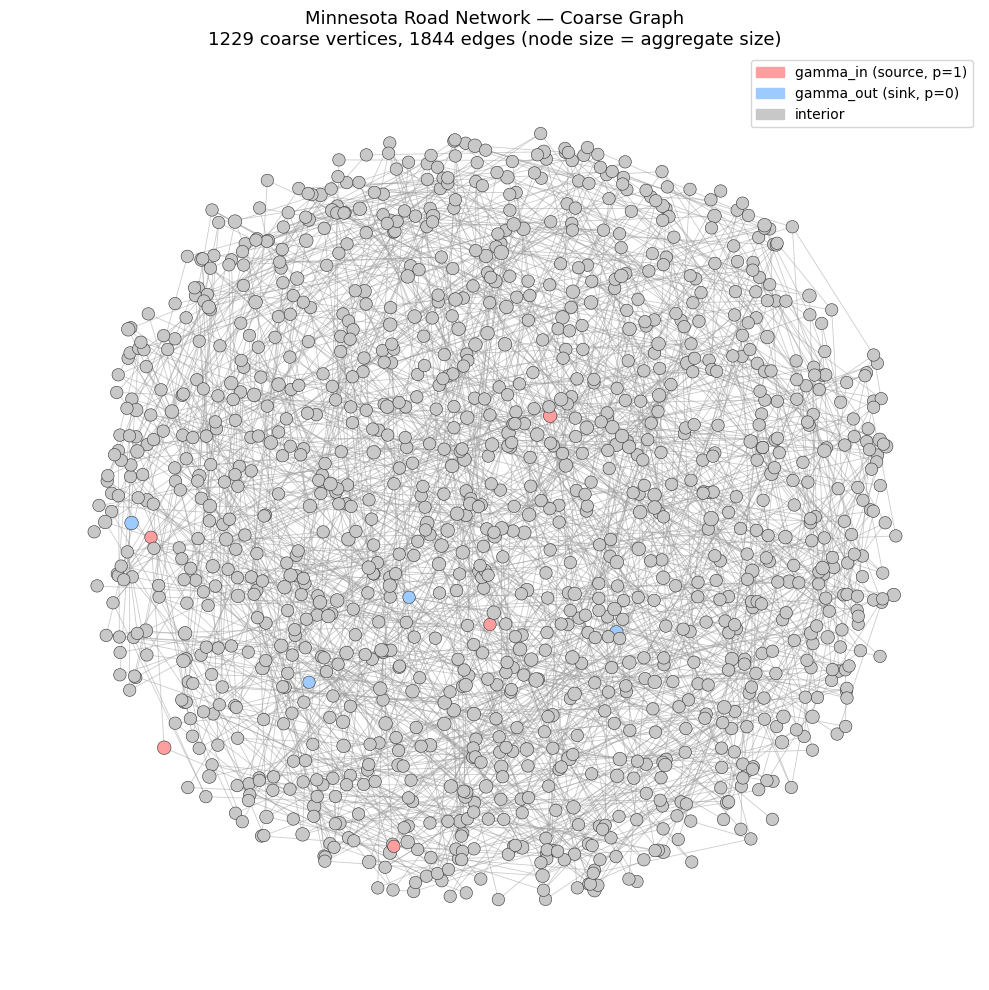

In [67]:
visualize_coarse_graph(setup, aggregate_of, title="Minnesota Road Network — Coarse Graph")

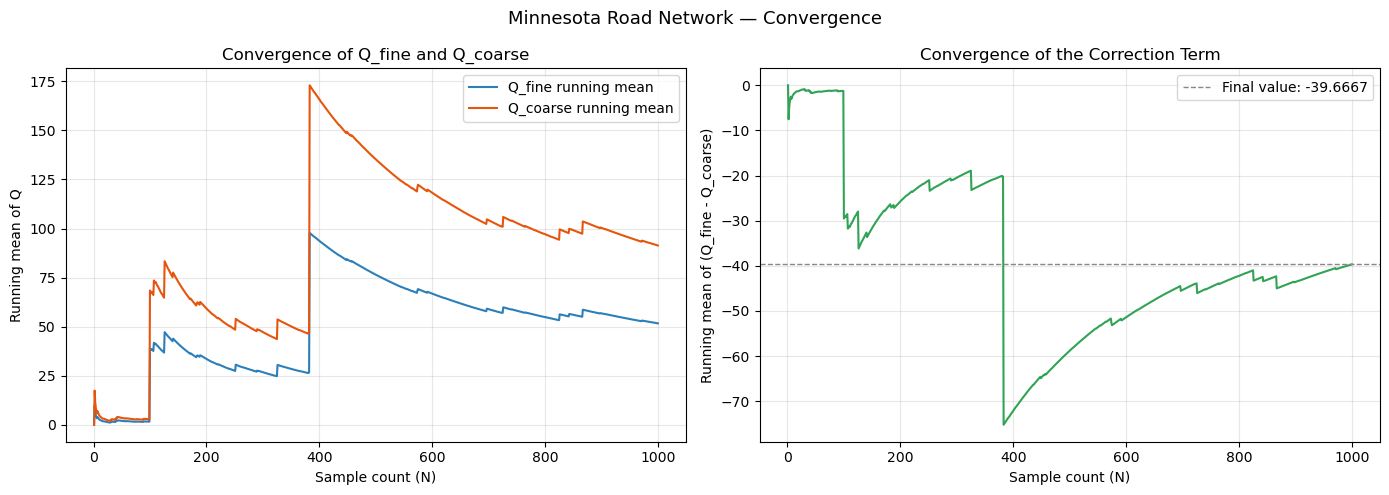

In [70]:
# call it
plot_convergence(result, title="Minnesota Road Network — Convergence")

In [73]:
result = run_paired_validation(setup, N=2000)

N = 1000 paired samples
Q_fine   : mean=51.680631  var=786840.359299
Q_coarse : mean=91.347335  var=2468576.926823
Q_fine - Q_coarse : mean=-39.666704  var=468042.403796
Correlation(Q_fine, Q_coarse): 1.0000
Variance reduction: 1.68x


In [85]:
result_100 = run_paired_validation(setup, N=1500)

N = 1500 paired samples
Q_fine   : mean=41.321869  var=535154.761801
Q_coarse : mean=73.010474  var=1678285.763488
Q_fine - Q_coarse : mean=-31.688605  var=318041.607794
Correlation(Q_fine, Q_coarse): 1.0000
Variance reduction: 1.68x


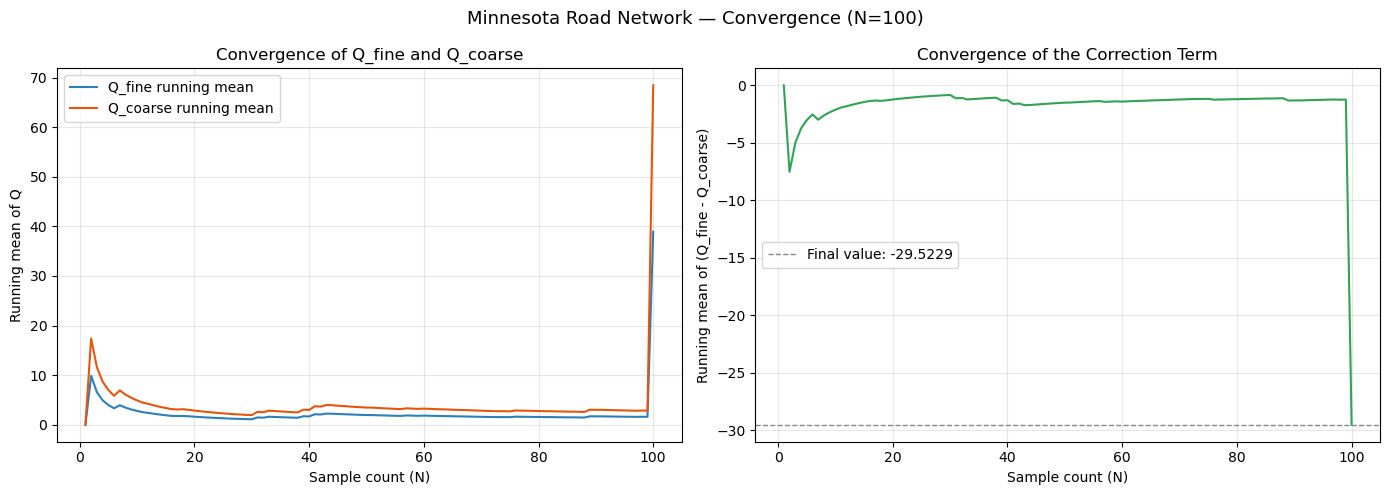

In [77]:
plot_convergence(result_100, title="Minnesota Road Network — Convergence (N=100)")

In [89]:
estimate = two_level_estimate(setup, result_100, N_coarse_only=3500)

Coarse-only base estimate (N=3500): 178.821528
Correction term mean (paired samples): -31.688605
Two-level estimate of E[Q_fine]: 147.132923
Direct fine-only mean (for comparison): 41.321869


In [92]:
Q_coarse_only_full = np.array([run_coarse_only_sample(setup, seed=100000+n) for n in range(3500)])

print("min:", Q_coarse_only_full.min())
print("max:", Q_coarse_only_full.max())
print("median:", np.median(Q_coarse_only_full))
print("mean:", Q_coarse_only_full.mean())

median = np.median(Q_coarse_only_full)
extreme = Q_coarse_only_full[Q_coarse_only_full > 20 * median]
print(f"\nSamples > 20x median: {len(extreme)} out of 3500")
print(extreme)

min: 6.956537298154701e-08
max: 191231.77675867712
median: 0.1014572782885038
mean: 178.82152761758724

Samples > 20x median: 759 out of 3500
[7.64235042e+02 4.26472035e+01 4.92510909e+00 2.29737069e+00
 4.81341677e+01 2.32326444e+00 1.11501690e+01 5.02900960e+00
 2.77380591e+01 5.43755756e+01 4.78393710e+00 2.23776529e+00
 1.72860269e+02 2.25896737e+02 4.44385809e+00 1.21033481e+01
 2.17568661e+00 5.83781967e+01 1.09817816e+01 2.19019987e+00
 8.01054099e+01 8.27543622e+00 6.40134348e+01 6.64605798e+00
 3.67870408e+01 1.21130179e+01 1.46564489e+01 4.85038873e+00
 2.59984807e+02 6.58218388e+01 1.57486828e+01 2.38863191e+01
 5.45105406e+01 2.78891974e+00 1.17834984e+01 4.85647824e+01
 1.30469471e+02 2.54503291e+02 8.98968551e+00 1.21197599e+01
 1.06505733e+01 3.27124598e+02 5.48673414e+00 3.17804931e+01
 3.38049547e+04 2.16620873e+00 3.75212756e+00 2.86621970e+02
 1.31673153e+01 2.86283475e+00 9.59899716e+00 2.39377444e+01
 2.07867533e+01 1.22141974e+04 3.66292327e+00 2.56201864e+00
 2.6